# GAN — generating digits from random noise

**Objective:** train a basic (vanilla) GAN on MNIST so the generator can turn random noise vectors into digit-like images. This notebook walks through the dataset, the generator/discriminator architectures, the adversarial loss, a short training run, and what the generated samples look like.

Note: this GAN only makes new images from noise — it doesn't take an input image and clean it up or reconstruct it. That's what OIDN and the VAE module do respectively.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.utils import make_grid

# so we can import the gan package from notebooks/
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT_DIR))

from gan.dataset import get_dataloader
from gan.model import Discriminator, Generator

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", device)

device: cuda


## Dataset samples

Real MNIST digits, normalized to [-1, 1] (same range the generator's Tanh output uses).

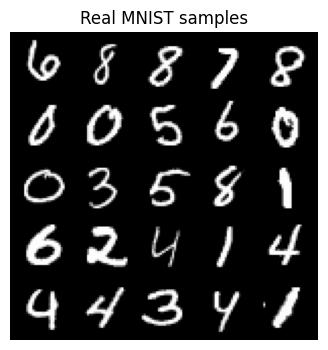

In [2]:
dataloader = get_dataloader(batch_size=64, dataset_name="mnist", data_dir=ROOT_DIR / "data")
real_batch, _ = next(iter(dataloader))

grid = make_grid(real_batch[:25], nrow=5, normalize=True)
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Real MNIST samples")
plt.show()

## Generator

Maps a 100-dim random noise vector through fully connected layers up to a 28x28 image. LeakyReLU + BatchNorm in the hidden layers, Tanh on the output so pixels land in [-1, 1].

In [3]:
latent_dim = 100
img_shape = (1, 28, 28)

generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
print(generator)

# sanity check: noise in, image out
z = torch.randn(4, latent_dim, device=device)
sample_out = generator(z)
print("output shape:", sample_out.shape, "range:", sample_out.min().item(), "to", sample_out.max().item())

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)
output shape: torch.Size([4, 1, 28, 28]) range: -0.06889325380325317 to 0.06397367268800735


## Discriminator

Maps a flattened image to a single "is this real?" probability (Sigmoid output). It's a plain binary classifier — the twist is just what it's trained on (a mix of real data and the generator's current fakes).

In [4]:
discriminator = Discriminator(img_shape=img_shape).to(device)
print(discriminator)

validity = discriminator(sample_out)
print("discriminator output shape:", validity.shape, "values:", validity.squeeze().tolist())

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
discriminator output shape: torch.Size([4, 1]) values: [0.504626452922821, 0.5042579770088196, 0.5036789178848267, 0.5038336515426636]


## Loss and adversarial training

Both networks use binary cross-entropy loss, since at each step it's just "real vs fake" classification:

- **Generator step:** generate fake images, run them through the discriminator, and push the generator's weights so the discriminator's output on those fakes gets closer to "real" (label 1). The generator never sees real images directly — it only learns from the discriminator's feedback.
- **Discriminator step:** show it a batch of real images (label 1) and the generator's fakes (label 0, and detached so this step doesn't update the generator), and push its weights to tell them apart better.

These two steps alternate every batch. Because each network is adapting to a constantly-changing opponent, the losses don't necessarily trend toward zero the way a normal training loss would — bouncing around is often a sign things are working, not broken.

In [5]:
adversarial_loss = nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

## Training (short run)

Just a handful of epochs here to see the training loop work end-to-end and watch sample quality improve a little — a real run uses `python gan/train.py --epochs 30` (see `gan/README.md`).

In [6]:
N_EPOCHS = 5
MAX_BATCHES_PER_EPOCH = 400  # keep this notebook run quick

history = {"g_loss": [], "d_loss": []}
sample_grids = []

fixed_z = torch.randn(25, latent_dim, device=device)  # same noise each epoch, so we can watch progress

for epoch in range(N_EPOCHS):
    g_loss_total, d_loss_total, n_batches = 0.0, 0.0, 0

    for i, (imgs, _) in enumerate(dataloader):
        if i >= MAX_BATCHES_PER_EPOCH:
            break
        batch_size = imgs.size(0)
        real_imgs = imgs.to(device)
        valid = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # generator step
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, latent_dim, device=device)
        gen_imgs = generator(z)
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)
        g_loss.backward()
        optimizer_G.step()

        # discriminator step
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(real_imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        g_loss_total += g_loss.item()
        d_loss_total += d_loss.item()
        n_batches += 1

    avg_g, avg_d = g_loss_total / n_batches, d_loss_total / n_batches
    history["g_loss"].append(avg_g)
    history["d_loss"].append(avg_d)
    print(f"epoch {epoch + 1}/{N_EPOCHS}  D loss: {avg_d:.4f}  G loss: {avg_g:.4f}")

    generator.eval()
    with torch.no_grad():
        sample_grids.append(make_grid(generator(fixed_z).cpu(), nrow=5, normalize=True))
    generator.train()

epoch 1/5  D loss: 0.5113  G loss: 0.8406
epoch 2/5  D loss: 0.4765  G loss: 1.0956
epoch 3/5  D loss: 0.4661  G loss: 1.2282
epoch 4/5  D loss: 0.4344  G loss: 1.3435
epoch 5/5  D loss: 0.3912  G loss: 1.5392


## Training loss

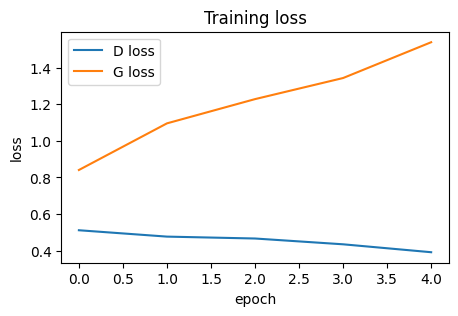

In [7]:
plt.figure(figsize=(5, 3))
plt.plot(history["d_loss"], label="D loss")
plt.plot(history["g_loss"], label="G loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training loss")
plt.show()

## Generated samples across epochs

Same fixed noise vectors each epoch, so any change below is the generator actually learning, not just different random noise.

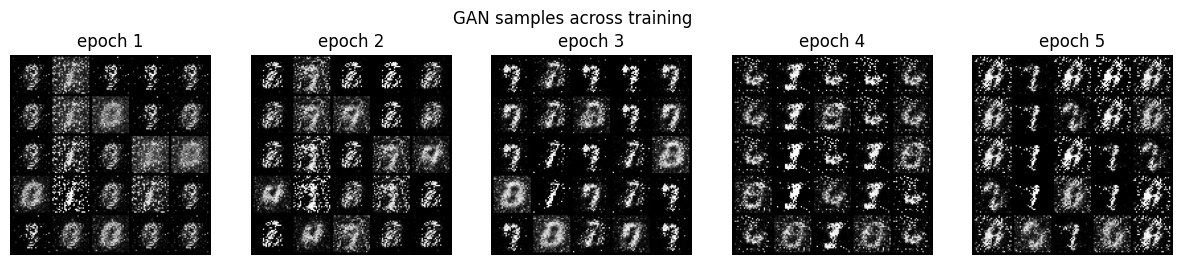

In [8]:
fig, axes = plt.subplots(1, N_EPOCHS, figsize=(3 * N_EPOCHS, 3))
for ax, grid, epoch in zip(axes, sample_grids, range(1, N_EPOCHS + 1)):
    ax.imshow(grid.permute(1, 2, 0), cmap="gray")
    ax.set_title(f"epoch {epoch}")
    ax.axis("off")
plt.suptitle("GAN samples across training")
plt.show()

## Final generated samples

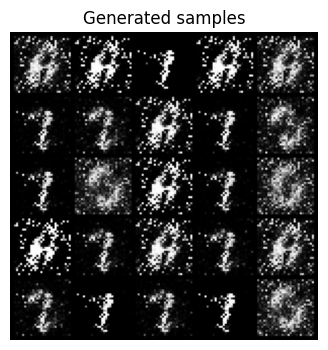

In [9]:
generator.eval()
with torch.no_grad():
    final_z = torch.randn(25, latent_dim, device=device)
    final_grid = make_grid(generator(final_z).cpu(), nrow=5, normalize=True)
generator.train()

plt.figure(figsize=(4, 4))
plt.imshow(final_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Generated samples")
plt.show()

## Observations

After just 5 short epochs (400 batches each, not even the full dataset per epoch), the samples already start showing blurry digit-like blobs with some stroke structure, but they're far from sharp — that takes the full 30+ epoch run in `gan/train.py`. The loss curves above don't monotonically decrease like a normal training loss would; D loss and G loss move around each other as the two networks keep adapting, which is expected for GANs rather than a sign of a bug.

Things worth watching for in a longer run:
- **Mode collapse** — if most of the generated grid starts looking like the same 1-2 digits, the generator has found a shortcut instead of learning the full digit variety.
- **Instability** — if D loss crashes to ~0, the discriminator is overpowering the generator and the generator's gradient signal becomes less useful.

For a full training run, use `python gan/train.py --epochs 30` (see `gan/README.md`), which also saves a sample grid per epoch to `results/gan/` so you can see the progression more clearly than the 5-epoch preview here.

## Follow-up: chasing the mode collapse in `gan/train.py`

The preview run above is too short to show it clearly, but the full `gan/train.py` run (25+ epochs) did show real mode collapse - generated digits clustering around a couple of shapes (mostly 2s and 3s) instead of covering all 10.

We tried two fixes:

1. **Just train longer** (75 vs 25 epochs) - made it worse, not better. The discriminator kept getting stronger the whole time (loss trending toward 0), so the generator's feedback signal kept getting weaker.
2. **Label smoothing** (train the discriminator to predict 0.9 instead of 1.0 for real images, `--label-smoothing`) - this worked as intended: D loss and G loss stopped drifting apart and settled into a stable range. But sample diversity barely changed.

**Takeaway:** label smoothing fixes discriminator overconfidence (a training-stability problem), but that's a different problem from mode collapse (the generator settling for a narrow set of outputs) - fixing them together isn't guaranteed. Actually improving diversity would need something that directly penalizes repeated outputs (minibatch discrimination) or a better-suited architecture (a convolutional DCGAN instead of this MLP GAN) - out of scope for a first basic GAN, but worth naming rather than glossing over. Full writeup in `gan/README.md`.

## Quantitative comparison: MLP vs DCGAN

Everything above is judged by eye. Here's an actual number: load both fully-trained generators (`models/gan/generator.pt` for MLP, `models/gan/generator_dcgan.pt` for DCGAN), generate a larger batch from each (200 images), and run them through a small separate digit classifier (`notebooks/eval_utils.py`) trained on real MNIST. Two things this tells us:

- **Average confidence** -- how sure the classifier is that each generated image is a real, recognizable digit. Higher usually means clearer/sharper samples.
- **Class spread** -- out of the 10 possible digits, how many different digits the classifier actually sees across the batch, and how evenly. This is a direct, numeric way to measure mode collapse instead of just eyeballing the sample grid.

This also regenerates the exact `results/gan/final_samples.png` and `results/gan/final_samples_dcgan.png` images used in the project README, straight from running this notebook.

In [10]:
sys.path.append(str(ROOT_DIR / "notebooks"))
from eval_utils import get_classifier, predict
from gan.inference import load_generator

MLP_CHECKPOINT = ROOT_DIR / "models" / "gan" / "generator.pt"
DCGAN_CHECKPOINT = ROOT_DIR / "models" / "gan" / "generator_dcgan.pt"
RESULTS_DIR = ROOT_DIR / "results" / "gan"
N_EVAL_SAMPLES = 200

classifier = get_classifier(device, data_dir=ROOT_DIR / "data")


def evaluate_generator(checkpoint_path, n=N_EVAL_SAMPLES):
    gen = load_generator(checkpoint_path, device=device)
    with torch.no_grad():
        z = torch.randn(n, gen.latent_dim, device=device)
        imgs = gen(z)  # [-1, 1]
    imgs_01 = (imgs.clamp(-1, 1) + 1) / 2  # rescale to [0, 1] for the classifier
    preds, conf = predict(classifier, imgs_01.cpu(), device)
    return imgs, preds, conf


mlp_imgs, mlp_preds, mlp_conf = evaluate_generator(MLP_CHECKPOINT)
dcgan_imgs, dcgan_preds, dcgan_conf = evaluate_generator(DCGAN_CHECKPOINT)

print(f"MLP    -- avg classifier confidence: {mlp_conf.mean():.1%}, unique digits seen: {mlp_preds.unique().numel()}/10")
print(f"DCGAN  -- avg classifier confidence: {dcgan_conf.mean():.1%}, unique digits seen: {dcgan_preds.unique().numel()}/10")


MLP    -- avg classifier confidence: 73.8%, unique digits seen: 7/10
DCGAN  -- avg classifier confidence: 82.3%, unique digits seen: 10/10


### Class distribution

How the classifier's predicted digit is spread across 200 samples from each generator. A collapsed generator piles up on 2-3 bars; a healthy one is closer to an even spread across all 10.

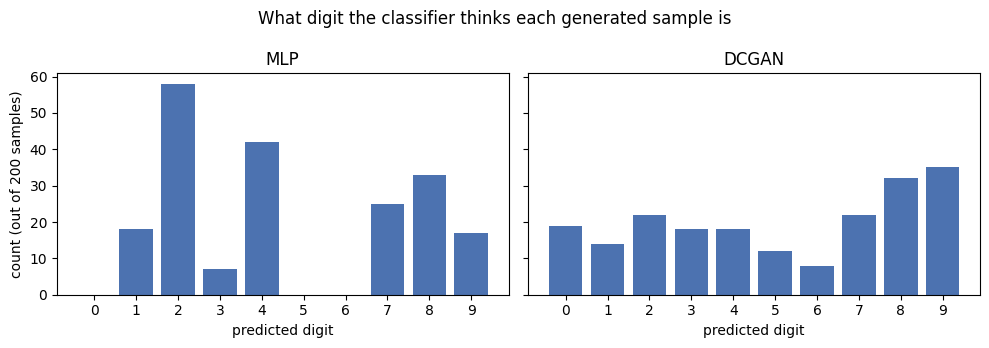

In [11]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

for ax, preds, title in zip(axes, [mlp_preds, dcgan_preds], ["MLP", "DCGAN"]):
    counts = np.bincount(preds.numpy(), minlength=10)
    ax.bar(range(10), counts, color="#4C72B0")
    ax.set_xticks(range(10))
    ax.set_xlabel("predicted digit")
    ax.set_title(title)

axes[0].set_ylabel("count (out of 200 samples)")
plt.suptitle("What digit the classifier thinks each generated sample is")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "class_distribution_comparison.png", bbox_inches="tight")
plt.show()


### Regenerating the sample grids used in the README

MLP samples:


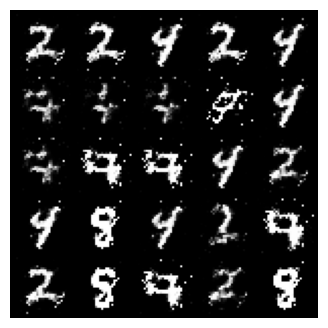

DCGAN samples:


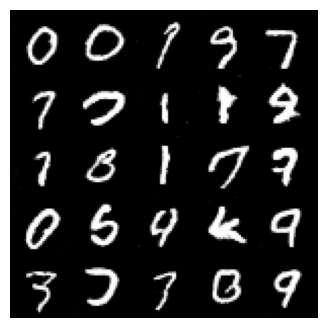

In [12]:
def save_sample_grid(imgs, path, n=25, nrow=5):
    grid = make_grid(imgs[:n].cpu(), nrow=nrow, normalize=True)
    plt.figure(figsize=(4, 4))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.savefig(path, bbox_inches="tight")
    plt.show()


print("MLP samples:")
save_sample_grid(mlp_imgs, RESULTS_DIR / "final_samples.png")

print("DCGAN samples:")
save_sample_grid(dcgan_imgs, RESULTS_DIR / "final_samples_dcgan.png")


## ROC curve: can each discriminator tell real from fake?

The discriminator's actual job is a binary classifier -- real vs. fake -- so an ROC curve is a direct fit here, not a stretch. Real MNIST test images are labeled 1, this generator's own freshly-generated fakes are labeled 0, and we sweep every possible threshold on the discriminator's raw output score to see how well it separates the two, independent of whatever specific threshold (0.5) it happens to use in practice.

AUC (area under the curve) summarizes it in one number: 1.0 is a perfect separator, 0.5 is no better than a coin flip.

MLP discriminator AUC: 0.982
DCGAN discriminator AUC: 0.981


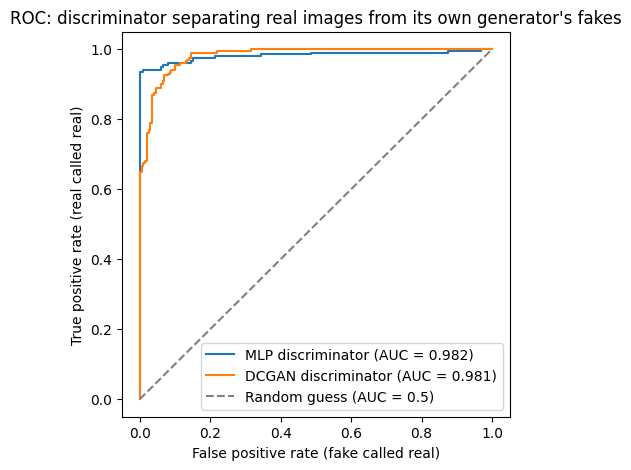

In [13]:
from gan.model import Discriminator, DCDiscriminator
from torch.utils.data import DataLoader
from eval_utils import roc_curve as compute_roc


def load_discriminator(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    architecture = ckpt.get("architecture", "mlp")
    cls = DCDiscriminator if architecture == "dcgan" else Discriminator
    disc = cls(img_shape=tuple(ckpt["img_shape"])).to(device)
    disc.load_state_dict(ckpt["state_dict"])
    disc.eval()
    return disc


MLP_DISC_CHECKPOINT = ROOT_DIR / "models" / "gan" / "discriminator.pt"
DCGAN_DISC_CHECKPOINT = ROOT_DIR / "models" / "gan" / "discriminator_dcgan.pt"

# A fresh batch of real images, same size as the fake batches evaluated above
real_eval_loader = DataLoader(dataloader.dataset, batch_size=N_EVAL_SAMPLES, shuffle=True)
real_imgs_roc, _ = next(iter(real_eval_loader))
real_imgs_roc = real_imgs_roc.to(device)

plt.figure(figsize=(5, 5))

for name, disc_checkpoint, fake_imgs in [
    ("MLP", MLP_DISC_CHECKPOINT, mlp_imgs),
    ("DCGAN", DCGAN_DISC_CHECKPOINT, dcgan_imgs),
]:
    disc = load_discriminator(disc_checkpoint, device)
    with torch.no_grad():
        real_scores = disc(real_imgs_roc).cpu().numpy().ravel()
        fake_scores = disc(fake_imgs.to(device)).cpu().numpy().ravel()

    scores = np.concatenate([real_scores, fake_scores])
    labels = np.concatenate([np.ones(len(real_scores)), np.zeros(len(fake_scores))])
    fpr, tpr, auc = compute_roc(scores, labels)
    plt.plot(fpr, tpr, label=f"{name} discriminator (AUC = {auc:.3f})")
    print(f"{name} discriminator AUC: {auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False positive rate (fake called real)")
plt.ylabel("True positive rate (real called real)")
plt.title("ROC: discriminator separating real images from its own generator's fakes")
plt.legend()
plt.savefig(RESULTS_DIR / "roc_curve.png", bbox_inches="tight")
plt.show()


## Final takeaway

The numbers above back up what the sample grids already suggested: the DCGAN's convolutional layers give it both a higher classifier confidence (clearer, less speckled digits) and a wider spread across the 10 classes (less mode collapse) than the plain MLP GAN, for the same training budget. The ROC/AUC result adds one more angle: it measures the *discriminator* side rather than the generator's output quality, and shows both discriminators still retain a real ability to separate real from fake at the end of training -- the adversarial game didn't collapse into either side trivially winning. See `gan/README.md` for the full experiment history (train longer -> label smoothing -> DCGAN) that led here.